# Clustering - Kümeleme

clustering benzer nesnelerin veya verilerin gruplar halinde toplanmasi demektir. Bu projede arabalari benzerliklerine göre gruplara ayiracağiz.

In [28]:
import pandas as pd

In [29]:
import warnings 
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df=pd.read_excel('cars.xls')

In [31]:
df.sample()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
571,19567.259291,2189,Pontiac,Grand Prix,Sedan 4D,Sedan,6,3.8,4,1,1,1


#### hatirlatma 
regression icin r2_score ve RMSE
Classification icin accuracy, precision, recall, fi-score 
Clustering silhouette score

In [32]:
x=df[['Price','Mileage','Cylinder']]

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [34]:
model=KMeans(4)

In [35]:
model=model.fit(x)

In [36]:
tahmin=model.predict(x)

In [37]:
x['cluster']=tahmin

In [38]:
x.head()

,Price,Mileage,Cylinder,cluster
0,17314.103129,8221,6,0
1,17542.036083,9135,6,0
2,16218.847862,13196,6,0
3,16336.913140,16342,6,3
4,16339.170324,19832,6,3


<Axes: xlabel='cluster', ylabel='count'>

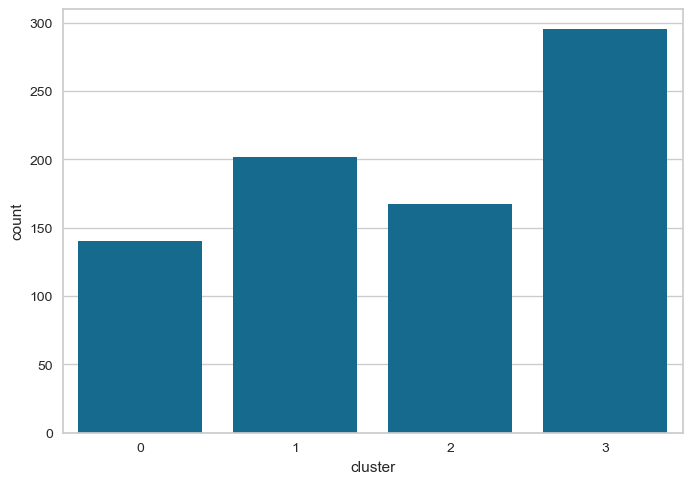

In [39]:
sns.countplot(x=x['cluster'])

In [40]:
silhouette_score(x, tahmin)

0.3368917153509355

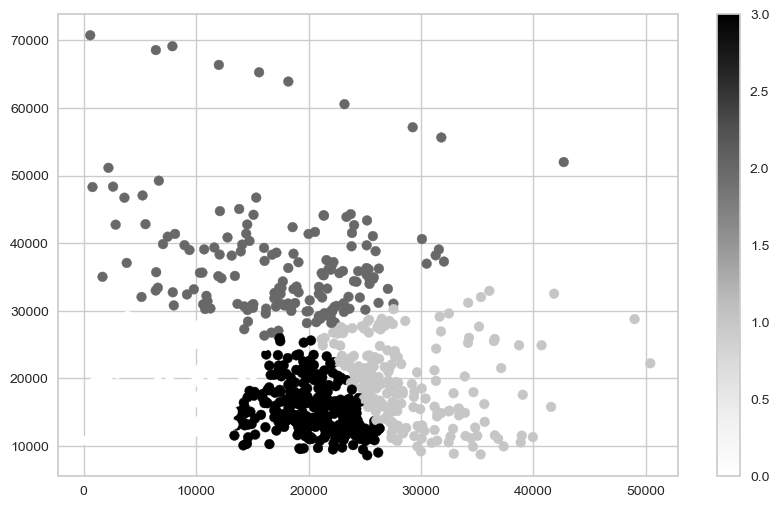

In [41]:
plt.figure(figsize=(10,6))
plt.scatter(x.Mileage,x.Price, c=tahmin)
plt.colorbar()

### dirsek nerede kirilirsa optimum nokta oradadiiir :) inertia, türev alıyor en optimum noktayı buluyor unsupervised ---

In [42]:
# wcss = within cluster sum of squares

wcss = []
ss = []

for i in range(2, 10):
    model = KMeans(i)
    model = model.fit(x)
    tahmin = model.predict(x)

    ss1 = silhouette_score(x, tahmin)
    ss.append(ss1)
    print(ss1)

    wcss.append(model.inertia_)


0.45114541424290505
0.4158475841722633
0.4133853217077484
0.38954737435596076
0.360283009536781
0.35947074777477916
0.3505066483020753
0.3472669527936587


In [43]:
from yellowbrick.cluster import KElbowVisualizer

In [47]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [50]:
data= linkage(x, method ='ward', metric='euclidean')

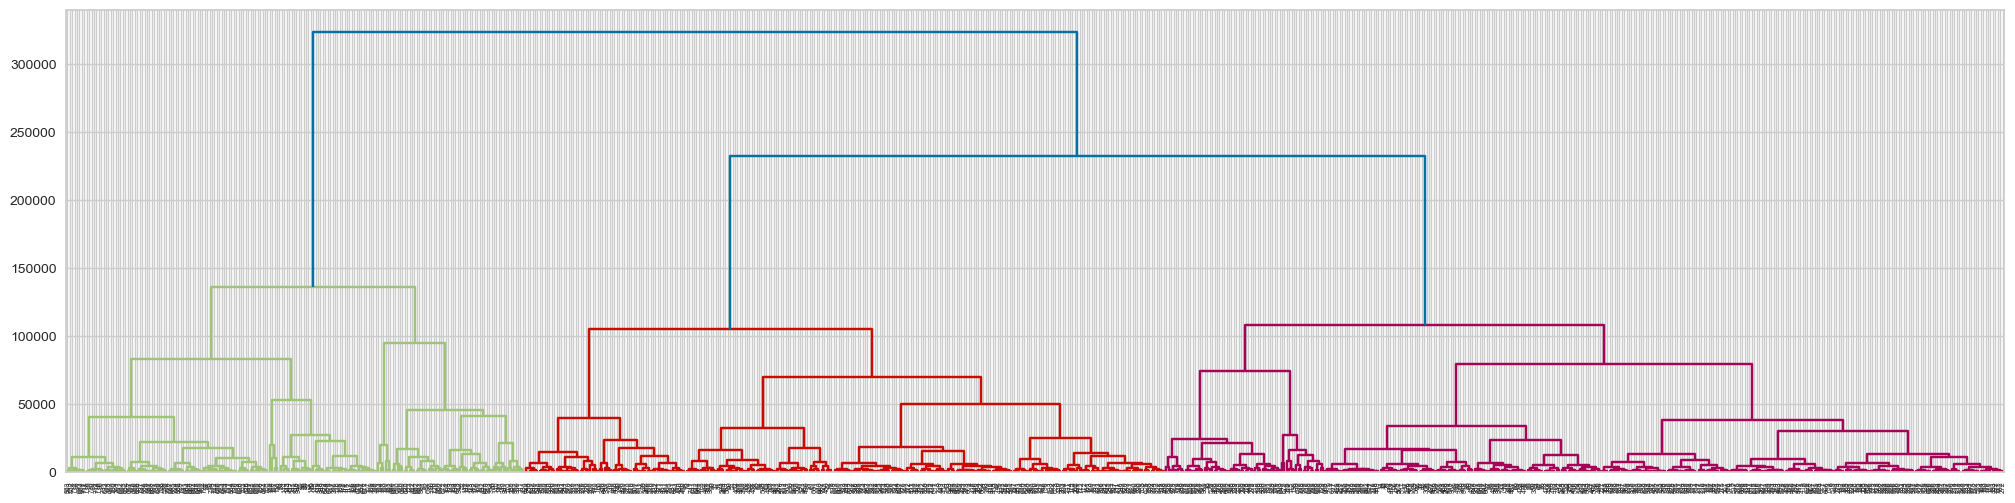

In [51]:
plt.figure(figsize=(25,6))
dendrogram(data);

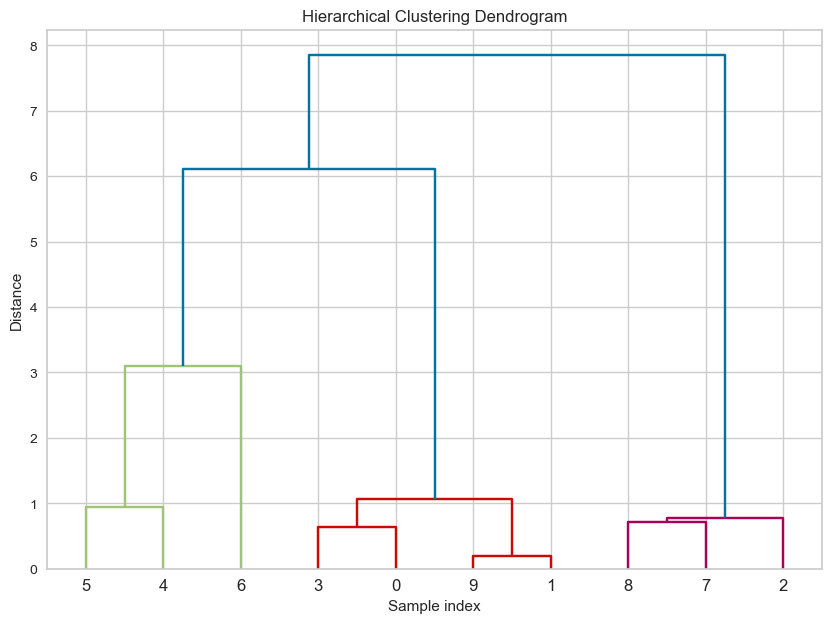

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage

# Generate sample data
X, _ = make_blobs(n_samples=10, centers=3, cluster_std=0.60, random_state=0)

# Perform hierarchical clustering
linked = linkage(X, 'ward')

# Create a dendrogram
plt.figure(figsize=(10, 7))
dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

In [54]:
from sklearn.cluster import DBSCAN

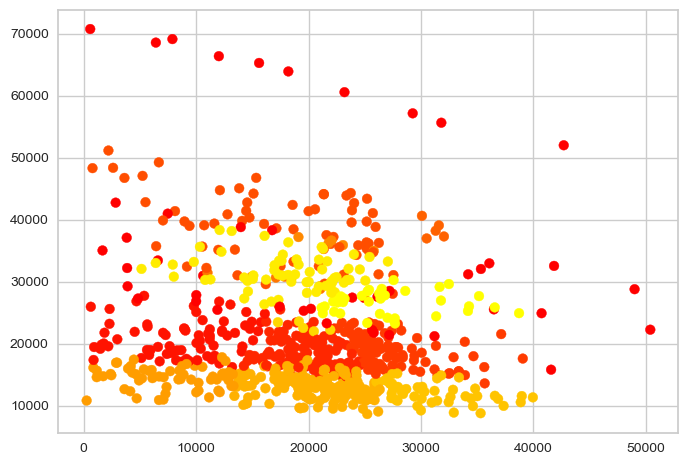

In [55]:
from sklearn.cluster import DBSCAN

db = DBSCAN(min_samples=5)

from sklearn.preprocessing import StandardScaler
x2 = StandardScaler().fit_transform(x)

y = db.fit_predict(x2)

plt.scatter(x['Mileage'], x['Price'], c=y, cmap='autumn');
plt.savefig('clustering.png', dpi=300)


In [57]:
df=pd.read_csv('Billionaires.csv')

In [58]:
df.head()

,rank,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,...,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,latitude_country,longitude_country
0,1,211000,Fashion & Retail,Bernard Arnault & family,74.0,France,Paris,LVMH,Fashion & Retail,France,...,1.1,"$2,715,518,274,227",65.6,102.5,82.5,24.2,60.7,67059887.0,46.227638,2.213749
1,2,180000,Automotive,Elon Musk,51.0,United States,Austin,"Tesla, SpaceX",Automotive,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
2,3,114000,Technology,Jeff Bezos,59.0,United States,Medina,Amazon,Technology,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
3,4,107000,Technology,Larry Ellison,78.0,United States,Lanai,Oracle,Technology,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
4,5,106000,Finance & Investments,Warren Buffett,92.0,United States,Omaha,Berkshire Hathaway,Finance & Investments,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891


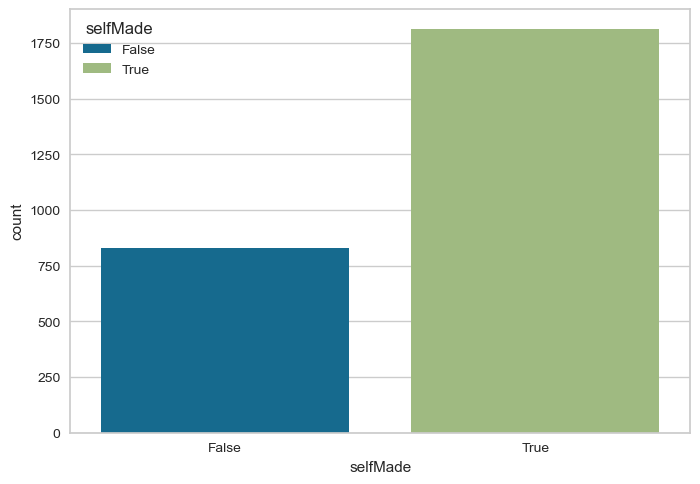

In [62]:
sns.countplot(x=df['selfMade'], hue=df['selfMade']);

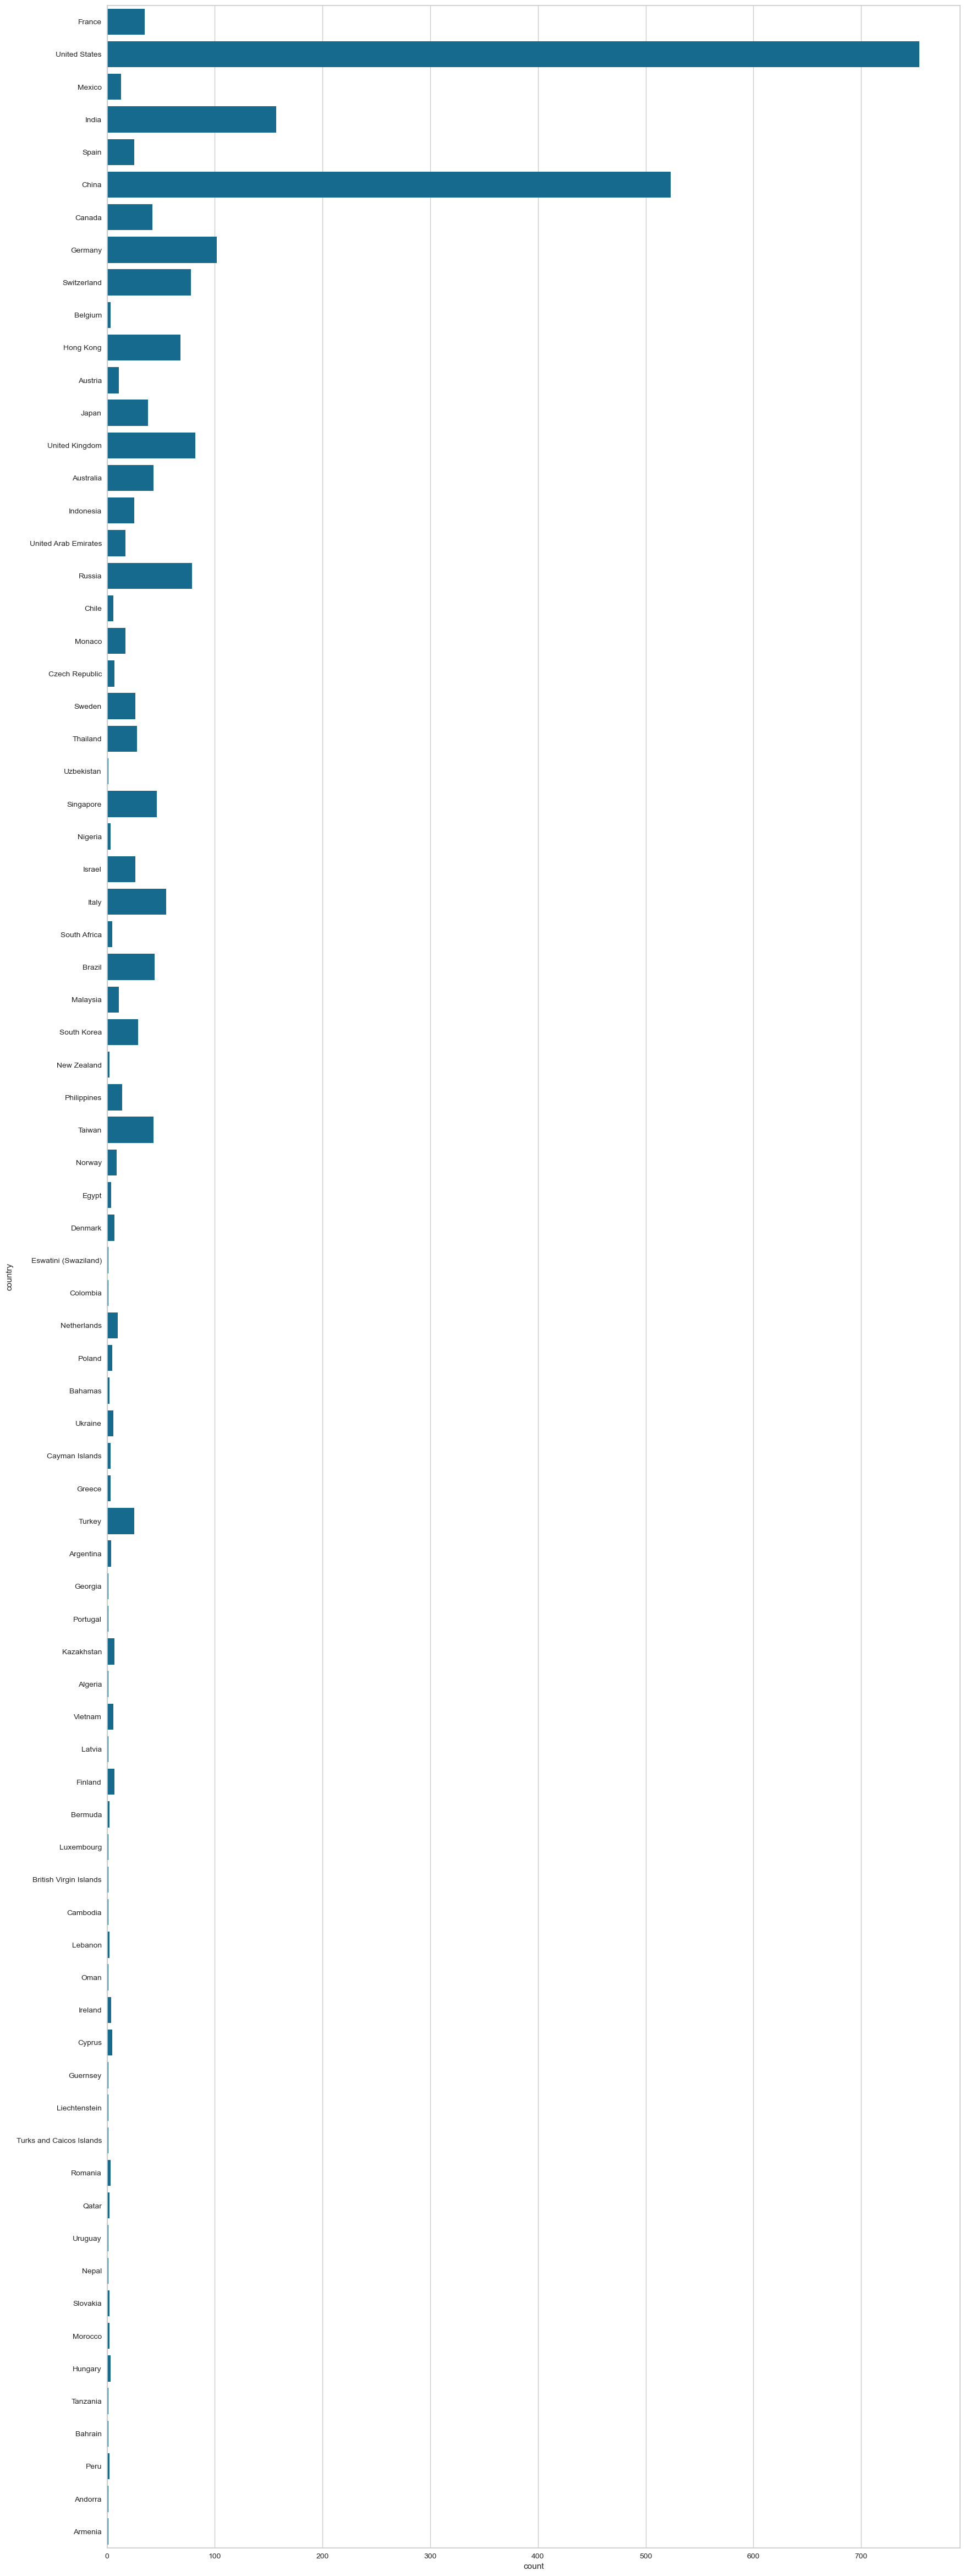

In [63]:
plt.figure(figsize=(20,60))
sns.countplot(y=df['country']);

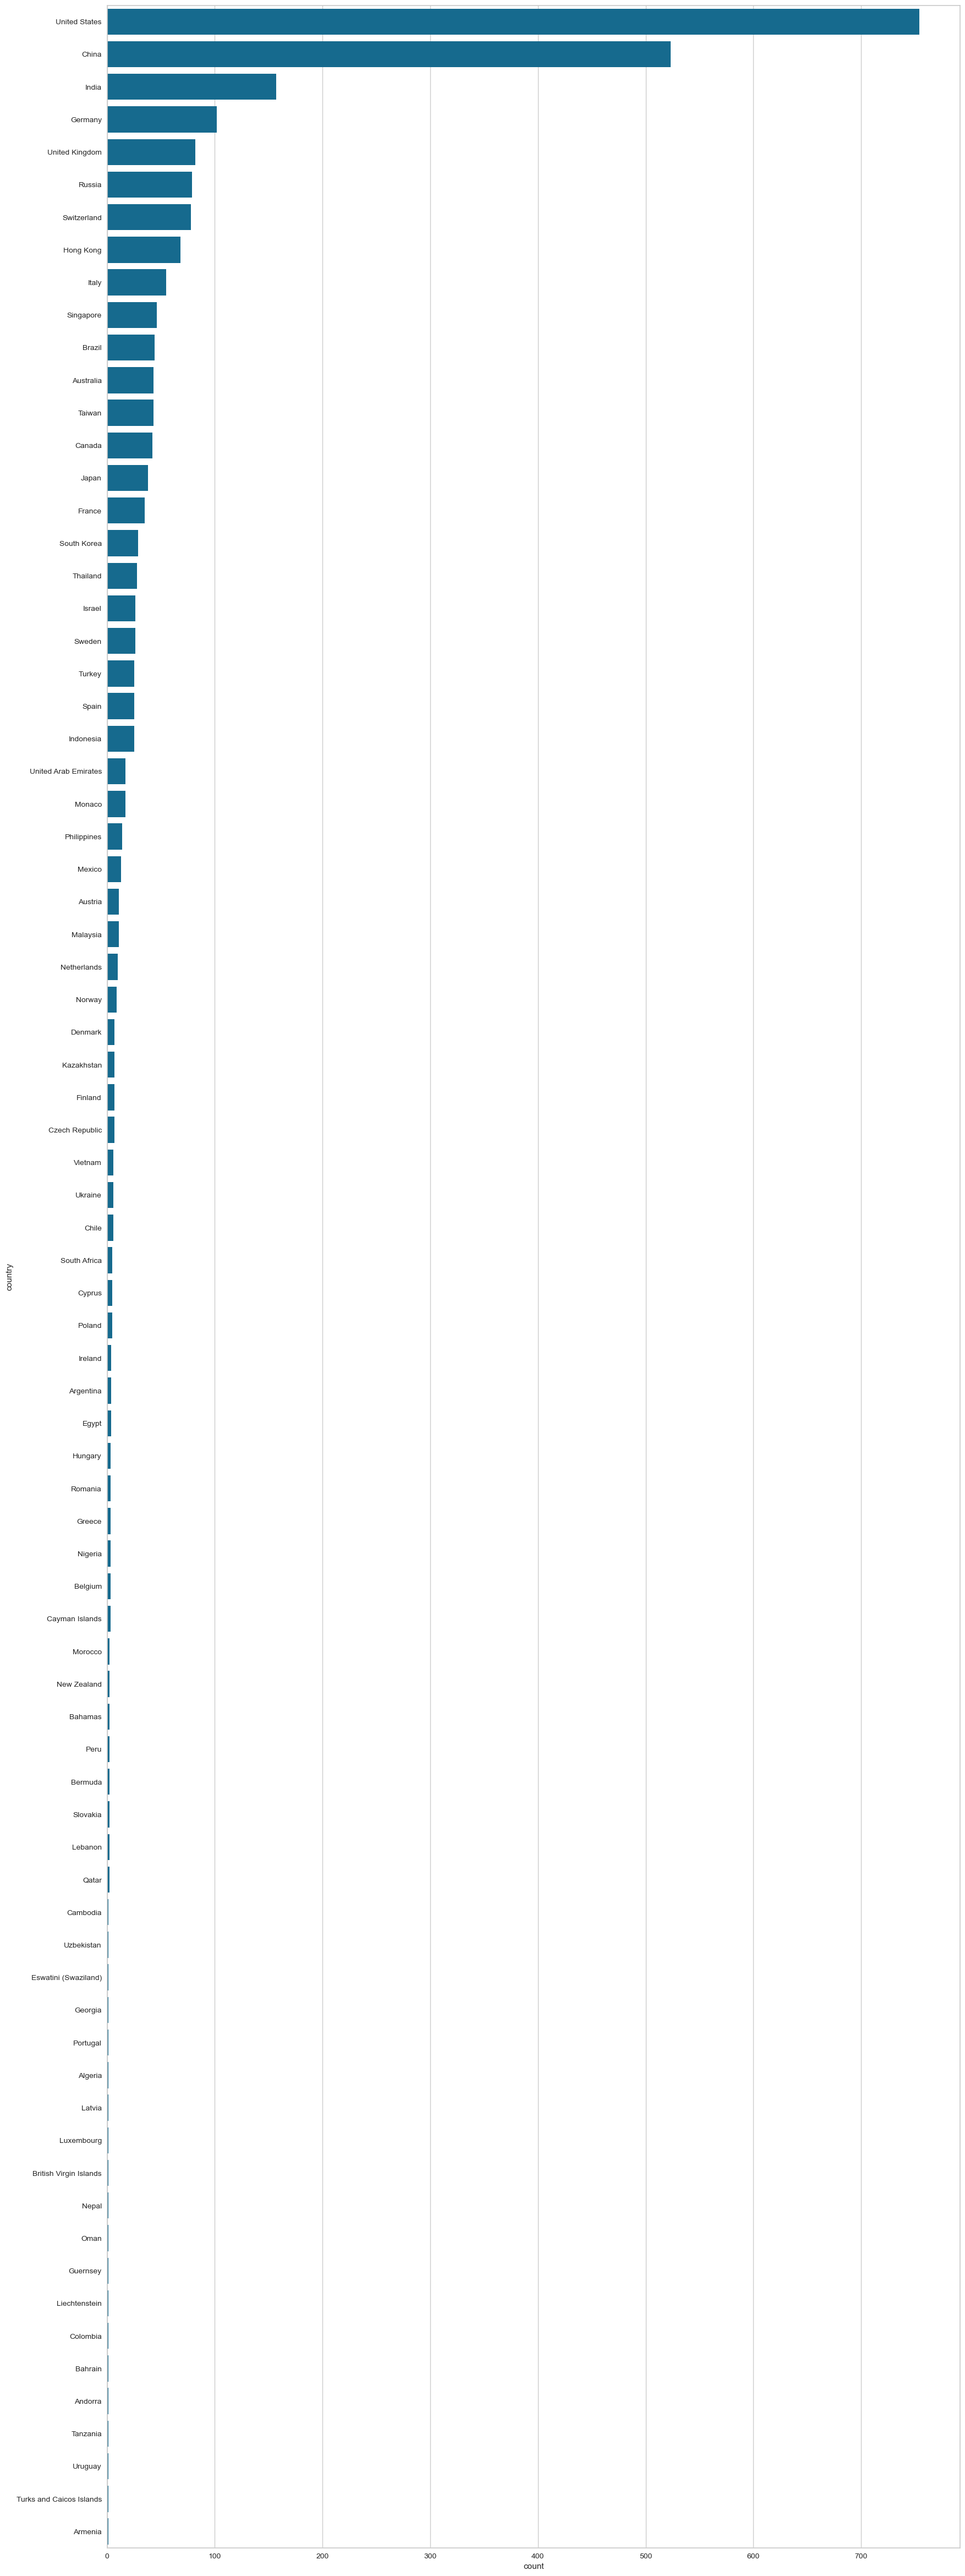

In [64]:
ydf = df['country'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(20,60))
sns.countplot(y=df['country'], order=ydf.index);


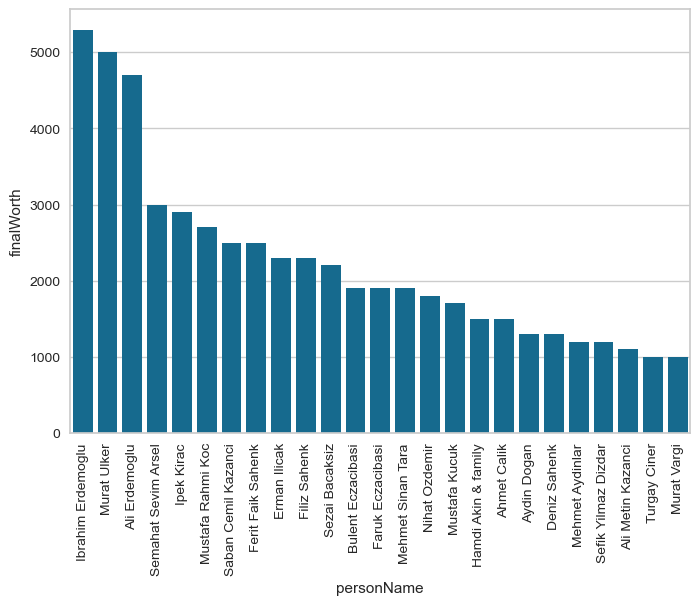

In [65]:
tr = df[df['country'] == 'Turkey']

sns.barplot(x=tr['personName'], y=tr['finalWorth'])
plt.xticks(rotation=90);

<Axes: xlabel='selfMade', ylabel='count'>

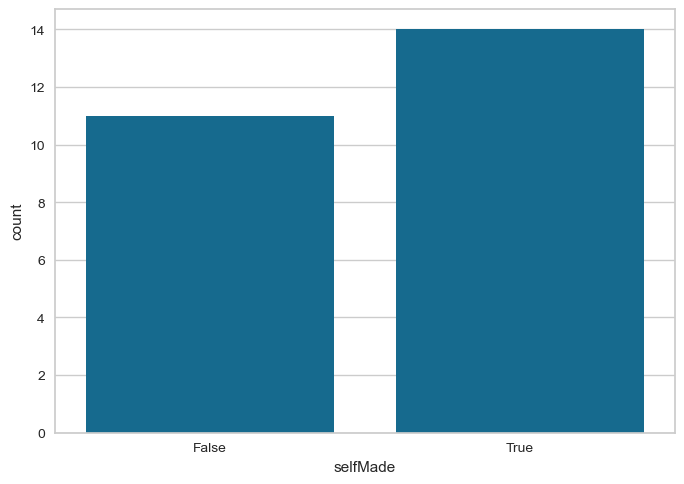

In [66]:
sns.countplot(x=tr['selfMade'])

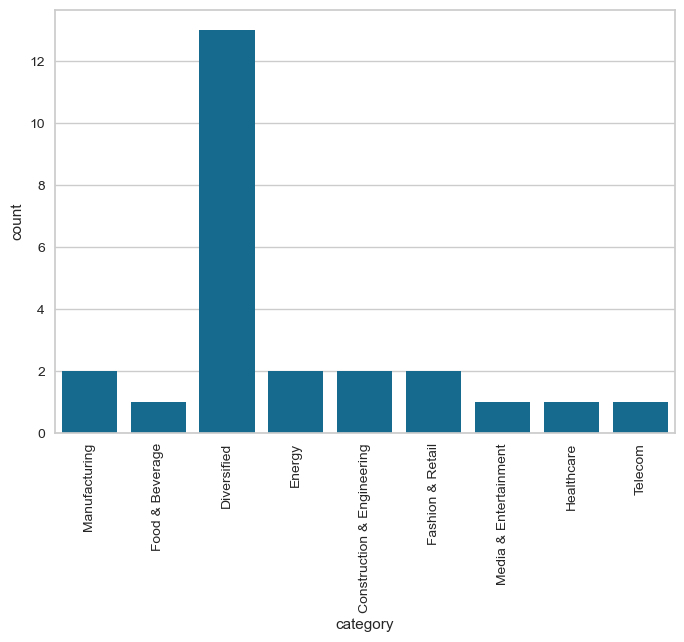

In [67]:
sns.countplot(x=tr['category'])
plt.xticks(rotation=90)
plt.show()

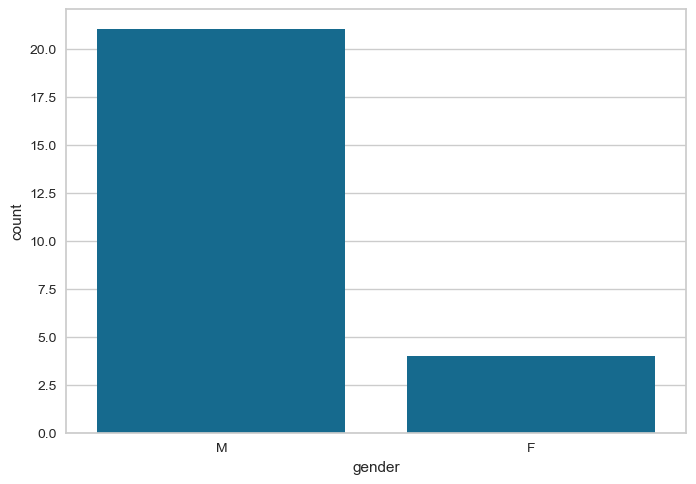

In [68]:
sns.countplot(x=tr['gender']);